### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P146 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

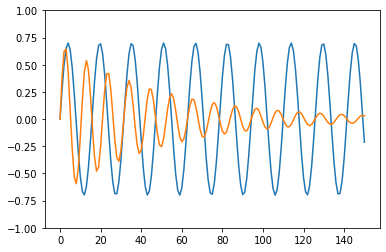

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 5

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

146

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00037362947072524356   1.820697546005249 sec       
199: 0.0002753261576606189   2.7742621898651123 sec       
299: 0.00023217011563404145   3.7980806827545166 sec      
399: 0.00020761389855609332   4.766352415084839 sec       
499: 0.00018843342624948255   5.738528251647949 sec       
599: 0.0001707432609852144   6.535429000854492 sec        
699: 0.00015313883393756824   7.397477149963379 sec       
799: 0.00013481412233978937   8.268922090530396 sec       
899: 0.00011873699587906472   9.10287094116211 sec       
999: 0.00010614492712036268   9.918150663375854 sec      
1099: 0.002173392239004378   10.764625787734985 sec        
1199: 0.000284737180920174   11.64706563949585 sec         
1299: 0.00021101830852860923   12.505821704864502 sec      
learning rate: 0.1
1399: 0.0003756230861567973   13.32579779624939 sec        
1499: 0.00027055297662255943   14.125167846679688 sec      
1599: 0.00022954936279468785   14.933131694793701 sec      
learning rate: 

26699: 0.003894949120068495   239.57127022743225 sec       
26799: 0.00027881272343725403   240.46637797355652 sec      
26899: 0.00022467917084612868   241.33109211921692 sec      
26999: 0.00020356876813908877   242.23014855384827 sec      
27099: 0.00018645204030602318   243.17575478553772 sec      
27199: 0.00017415636980828948   244.07027101516724 sec      
27299: 0.00016367550682852718   244.94980812072754 sec      
27399: 0.0005725234292647145   245.82593202590942 sec       
27499: 0.00014605672582791292   246.80975723266602 sec      
27599: 0.0001394923835755219   247.70658659934998 sec       
27699: 0.00013385390051316002   248.60564732551575 sec      
27799: 0.00012837049576740152   249.4955027103424 sec       
27899: 0.00013044866250117338   250.3487844467163 sec       
27999: 0.0001198490436465864   251.20383024215698 sec       
28099: 0.00011444465385551463   252.08483982086182 sec      
28199: 0.0001930896607315505   252.9925618171692 sec        
28299: 0.0001608962891774

53199: 4.1705088469961664e-05   477.99929213523865 sec      
53299: 4.313929875253966e-05   478.91246461868286 sec       
53399: 4.098388790947095e-05   479.7673201560974 sec        
53499: 4.0406565470243546e-05   480.7020652294159 sec       
53599: 3.975475213186105e-05   481.56554436683655 sec       
53699: 3.928441243251854e-05   482.45198249816895 sec       
53799: 3.9883187990477607e-05   483.31139278411865 sec      
53899: 3.980417250123278e-05   484.1736788749695 sec        
53999: 3.852654478685931e-05   485.04273533821106 sec       
54099: 3.814814963787491e-05   485.9808270931244 sec        
54199: 6.47183191243255e-05   486.89121985435486 sec        
54299: 4.370214381253981e-05   487.78165555000305 sec       
54399: 4.4248765114590154e-05   488.6234562397003 sec       
learning rate: 0.025
54499: 0.0002510181911691003   489.4734048843384 sec        
54599: 0.00016227016683628638   490.46059560775757 sec      
learning rate: 0.0125
54699: 4.105097578689962e-05   491.3606543

79899: 0.00023979455602775703   719.6407117843628 sec      
79999: 0.00020219225191037441   720.6127321720123 sec      
80099: 0.00018434854832807498   721.5562555789948 sec      
80199: 0.00016963963009577958   722.5232722759247 sec      
80299: 0.00015666061407428527   723.4916775226593 sec      
80399: 0.0001475318919325756   724.4232110977173 sec       
80499: 0.00014136203449084675   725.4134774208069 sec      
80599: 0.00017407318284132494   726.349981546402 sec       
80699: 0.00014909930619130783   727.298830986023 sec       
80799: 0.0001383376888639516   728.2108201980591 sec       
80899: 0.00013037159122530065   729.1294469833374 sec      
80999: 0.00012237359240488622   730.0835063457489 sec      
81099: 0.0008269475661499057   731.0379056930542 sec       
81199: 0.00031999951208002894   732.0025827884674 sec      
81299: 0.00026934918684777575   732.9521720409393 sec      
learning rate: 0.1
81399: 0.0002582201728035564   733.899317741394 sec        
81499: 0.000204046727

106299: 0.00019426652325941297   966.478490114212 sec       
106399: 0.00014158362585413547   967.4031021595001 sec      
106499: 0.00012584233329395174   968.3370151519775 sec      
106599: 0.00011715724140235982   969.2915453910828 sec      
106699: 0.0001111636849070682   970.2895622253418 sec       
106799: 0.0001060866557785263   971.258022069931 sec        
106899: 0.00010136279002925714   972.2197341918945 sec      
106999: 9.686978153382344e-05   973.1691796779633 sec       
107099: 9.267316467662985e-05   974.1167109012604 sec      
107199: 8.889690594003065e-05   975.0650253295898 sec      
107299: 8.564684607446505e-05   976.0806803703308 sec      
107399: 8.294775967759472e-05   977.0236341953278 sec      
107499: 8.281695840628459e-05   977.9784443378448 sec       
107599: 7.923071824272862e-05   978.9599254131317 sec       
107699: 7.746975120286364e-05   979.9198489189148 sec      
107799: 8.27219807217402e-05   980.8759453296661 sec        
107899: 7.519099149745906e-05

...

273699: 8.147958707260587e-05   2631.2647309303284 sec       
273799: 8.118317331245522e-05   2632.0903527736664 sec      
learning rate: 0.2
273899: 0.0009657696257313048   2632.93040394783 sec        
273999: 0.00023554528671939663   2633.7560489177704 sec      
274099: 0.00020098768336260413   2634.589822769165 sec       
274199: 0.00043734827505743093   2635.4366574287415 sec      
274299: 0.00018019164281401142   2636.307368516922 sec       
274399: 0.0001526113627356464   2637.1659564971924 sec       
274499: 0.00013873202698442207   2638.0404164791107 sec      
274599: 0.00012470013936232704   2638.8835031986237 sec      
274699: 0.0001379330948961397   2639.70245718956 sec         
274799: 0.00013264750824915444   2640.5310974121094 sec      
274899: 0.00010485680695393625   2641.3460421562195 sec      
274999: 0.00014422674388164382   2642.183474302292 sec       
275099: 9.260009381442072e-05   2643.009579896927 sec        
275199: 9.757755338538152e-05   2643.8349707126617 se

299299: 0.000470431453568358   2844.844852209091 sec        
299399: 0.000292502285710228   2845.674674987793 sec         
299499: 0.00023907137133538582   2846.5795605182648 sec      
299599: 0.00034645963727164607   2847.414888858795 sec       
299699: 0.0002045540335008015   2848.2314052581787 sec       
299799: 0.00018446258202706937   2849.041034221649 sec       
299899: 0.000174417849655711   2849.8827233314514 sec        
299999: 0.0001592004967364833   2850.748146533966 sec        
300099: 0.00014584328945765437   2851.5828034877777 sec      
300199: 0.0004974701444803682   2852.4176766872406 sec       
300299: 0.0001319754982254056   2853.244629383087 sec        
300399: 0.0006118204361468714   2854.080203294754 sec        
300499: 0.000258841095731546   2854.91392660141 sec          
300599: 0.00021039321798565095   2855.742578983307 sec       
learning rate: 0.1
300699: 0.00014402066888663919   2856.60280752182 sec        
300799: 0.0001191820057843553   2857.439625263214 se

324999: 0.00020846274258371278   3060.546554327011 sec       
325099: 0.00017235416057889805   3061.3673255443573 sec      
325199: 0.00014776904124168207   3062.1940116882324 sec      
325299: 0.0001326770139902366   3063.030777454376 sec        
325399: 0.000124068102339357   3063.863293170929 sec         
325499: 0.00011792737377147583   3064.6988866329193 sec      
325599: 0.00011264586129545834   3065.5138323307037 sec      
325699: 0.00010788657811457045   3066.3685574531555 sec      
325799: 0.00010348615964071152   3067.1853454113007 sec      
325899: 9.89646585287722e-05   3068.010721921921 sec         
325999: 9.412016669212912e-05   3068.823851585388 sec       
326099: 8.899509328026498e-05   3069.632819414139 sec       
326199: 8.370849001788722e-05   3070.5172004699707 sec      
326299: 7.839398879881905e-05   3071.4218924045563 sec      
326399: 7.32815669061595e-05   3072.2295298576355 sec       
326499: 6.85948792888217e-05   3073.090010404587 sec        
326599: 6.4471

350899: 0.0001824635637210214   3260.5826926231384 sec       
350999: 0.0001336062505763898   3261.322874069214 sec        
351099: 0.0001115608694098016   3262.040018558502 sec        
351199: 9.759993713369435e-05   3262.746283531189 sec        
351299: 8.884338703001804e-05   3263.4667477607727 sec      
351399: 8.39585892204119e-05   3264.1712124347687 sec       
351499: 8.06841882539268e-05   3264.9039509296417 sec       
351599: 7.79306751459469e-05   3265.607302427292 sec        
351699: 7.542523731024549e-05   3266.352687358856 sec       
351799: 7.306451022354041e-05   3267.0714342594147 sec      
351899: 7.078322664522267e-05   3267.799437522888 sec       
351999: 6.886961356150532e-05   3268.533679962158 sec        
352099: 6.657578629344139e-05   3269.254067182541 sec       
352199: 6.460579853234227e-05   3269.963023662567 sec       
352299: 6.274111668401777e-05   3270.67001748085 sec        
352399: 6.1009456344785194e-05   3271.3810493946075 sec      
352499: 6.04402015

376899: 0.00015464576467549309   3450.100806236267 sec       
376999: 9.043930419014877e-05   3450.8554430007935 sec       
learning rate: 0.0125
377099: 4.5202596268015504e-05   3451.604742050171 sec       
377199: 4.3387971463666194e-05   3452.321514606476 sec       
377299: 4.255232420249237e-05   3453.042895793915 sec        
377399: 4.1967263810273675e-05   3453.764441013336 sec       
377499: 4.151616994835077e-05   3454.464455604553 sec        
377599: 4.112693033385858e-05   3455.169895887375 sec        
377699: 8.302347091346894e-05   3455.874329328537 sec        
377799: 7.030314398496351e-05   3456.5907821655273 sec      
377899: 6.291431981717907e-05   3457.3333280086517 sec      
learning rate: 0.00625
377999: 4.3477922980894944e-05   3458.0679943561554 sec      
378099: 4.2313879847085495e-05   3458.795382499695 sec       
378199: 4.1872214304317186e-05   3459.5200979709625 sec      
378299: 4.157310296657702e-05   3460.236739397049 sec        
378399: 4.133556041068555e-

In [23]:
minLoss

Array(3.34945556e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

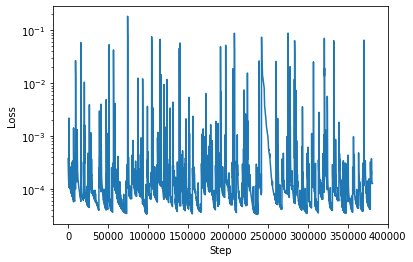

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

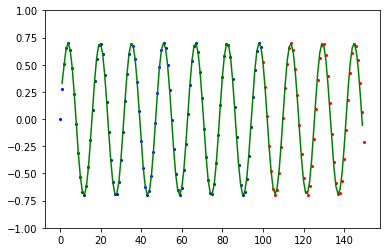

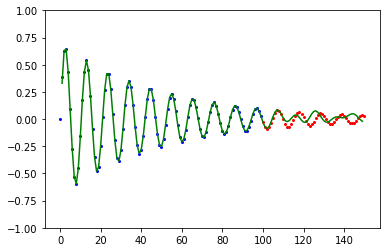

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

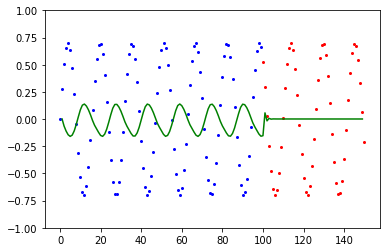

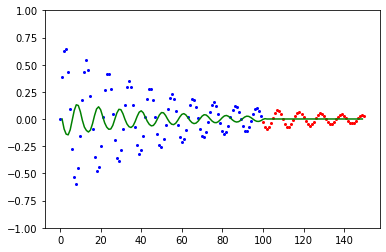

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[150900,
 Array(4.11502687e-05, dtype=float64),
 Array(0.00036642, dtype=float64),
 [(Array([[-0.40863734, -0.56524697,  0.0031258 , -0.25795833, -0.38726401]],      dtype=float64),
   Array([[-0.28766281,  0.40988463, -0.3495319 ,  0.17107719,  0.11887861],
          [ 0.62213064, -0.6971244 ,  0.23400206,  0.1491723 ,  0.20013127],
          [ 0.17924176, -0.02136658,  0.50948787, -0.19556051, -0.98496904],
          [ 0.37959082,  1.00702161,  0.6976712 ,  0.91514831,  0.10161415],
          [-0.53547513, -0.11402972, -0.99806475, -0.46608169,  0.41004119]],      dtype=float64),
   Array([ 0.00540182, -0.01108067,  0.01991823, -0.00299172, -0.00953863],      dtype=float64),
   Array([[ 3.52086559, -0.98061709,  1.47321494,  0.7988056 , -1.01889578]],      dtype=float64),
   Array([[-0.63277343, -7.72348118,  3.05580677, -3.62997014, -0.17117603],
          [-3.98273795, -4.42156481, -1.00358397, -3.42385942, -3.24655619],
          [-1.63558365,  5.58205064, -2.33189985,  3.54401001

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

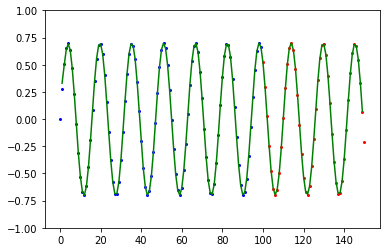

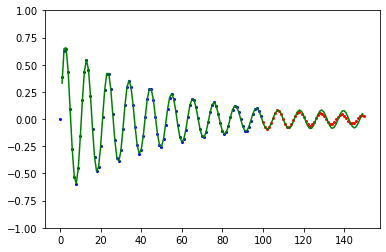

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [150900, Array(4.11502687e-05, dtype=float64), Array(0.00036642, dtype=float64)]
8400 5.824132454613849e-05 0.17780969852076328


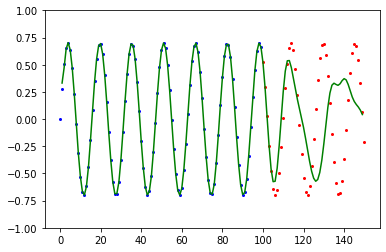

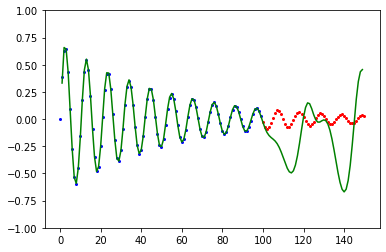

19200 6.07028026765324e-05 0.7768757550364629


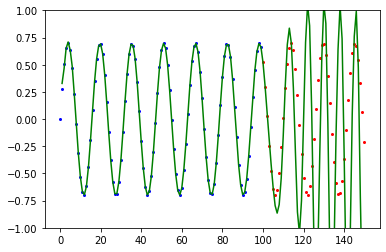

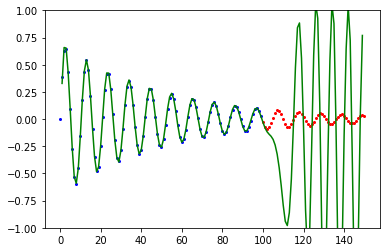

26500 4.435900067166399e-05 3.568809578549692


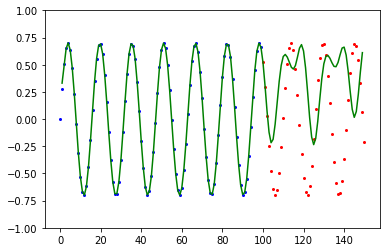

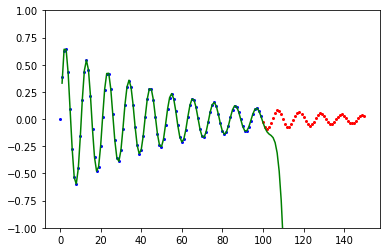

38600 3.9147935813875904e-05 0.13233145554165865


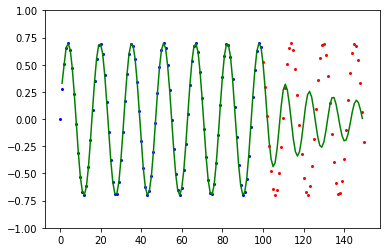

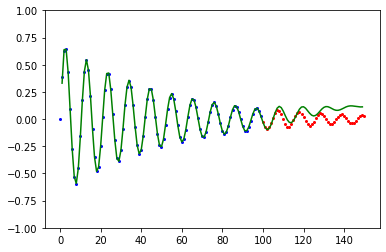

49900 4.101026201392609e-05 3.178640334150757


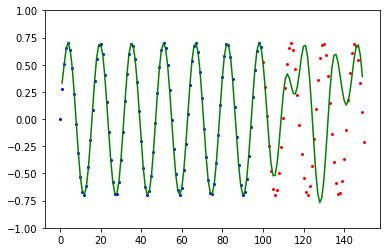

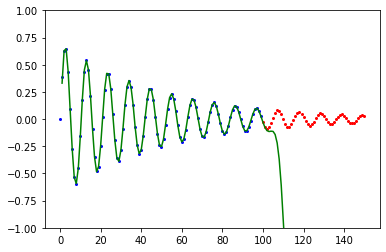

55800 3.5917573992221085e-05 0.15127384250658132


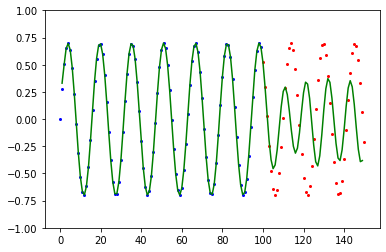

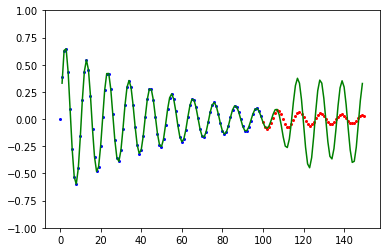

73400 3.4099393086726025e-05 0.08466730443935978


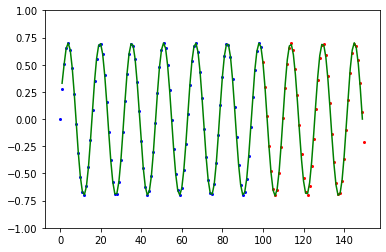

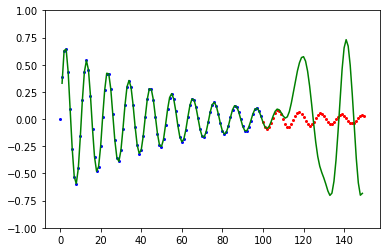

79700 6.474275915049728e-05 0.043106246888149756


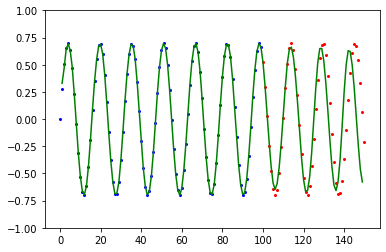

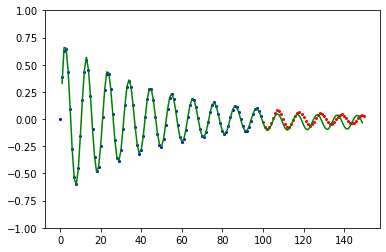

85900 7.229897507923897e-05 0.2284296849534742


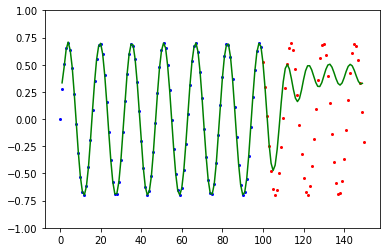

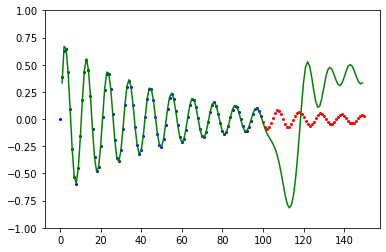

90500 7.021963104700782e-05 0.17000429060005495


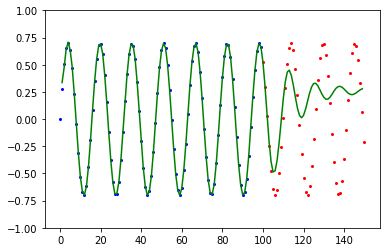

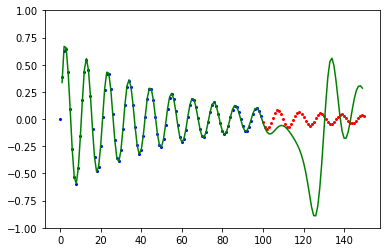

99000 3.363294172703273e-05 0.4148131678598702


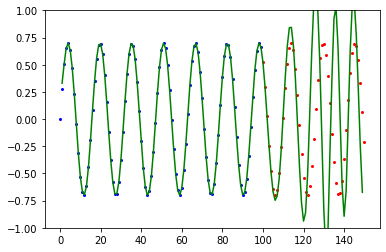

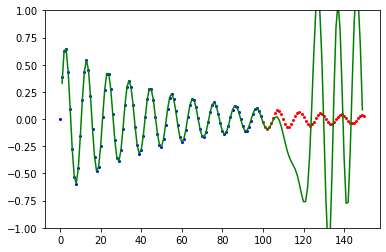

104000 6.373221287264125e-05 0.2747050822293653


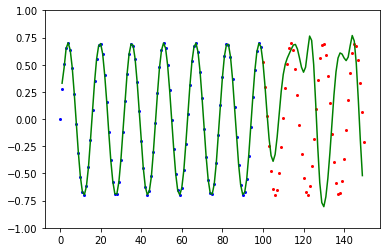

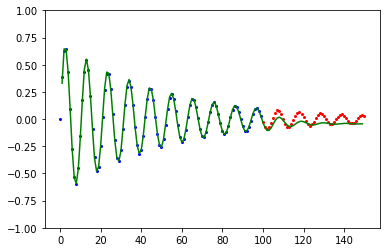

111900 5.621549218154723e-05 0.0752633012926355


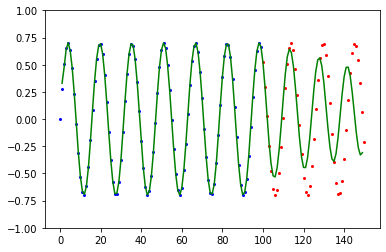

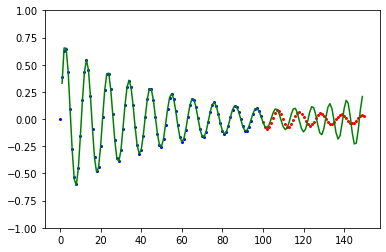

121700 6.787712211516928e-05 0.06990076536443525


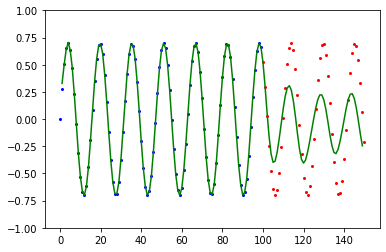

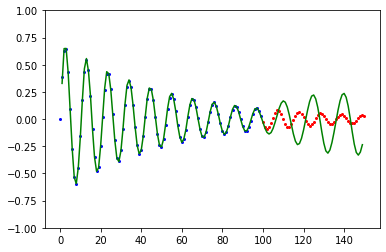

126000 5.481190109105848e-05 0.09029603908224872


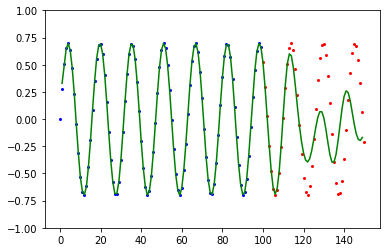

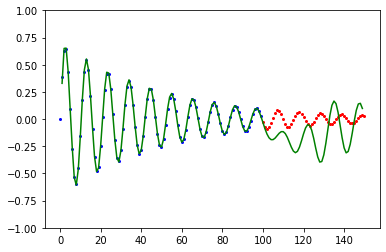

130800 4.6160938185168725e-05 0.19680414893705664


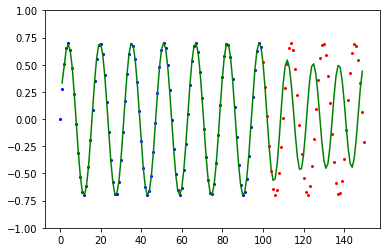

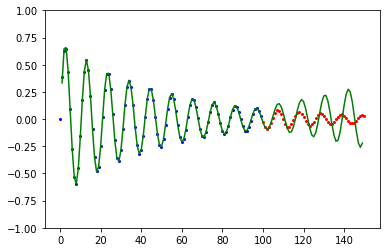

136800 3.72329801417134e-05 0.8071925409540421


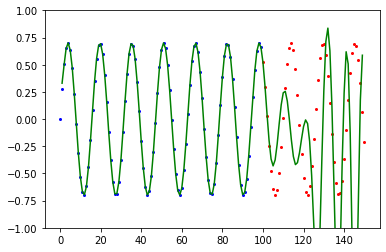

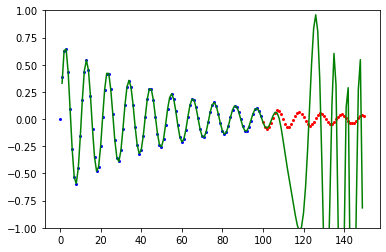

141100 4.764851186413937e-05 0.20964198157553923


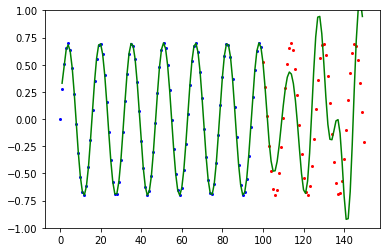

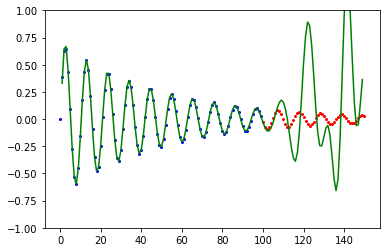

146800 3.8433218746630696e-05 0.6219657839879212


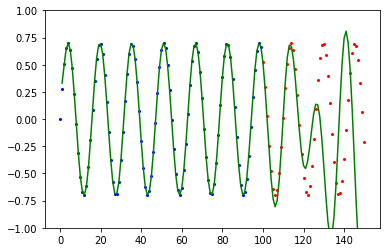

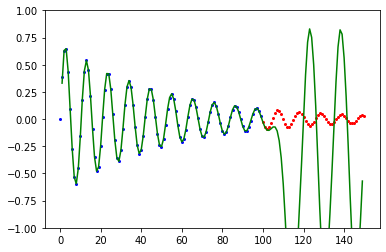

150900 4.115026874284535e-05 0.0003664195800800943


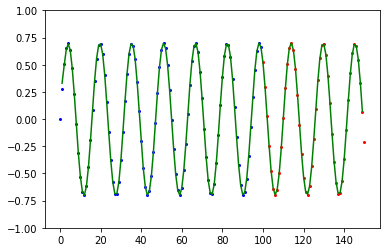

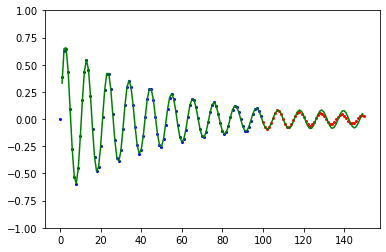

155700 3.3708881645961454e-05 4.2394010641827125


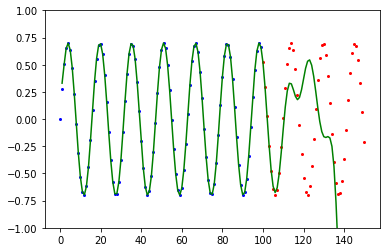

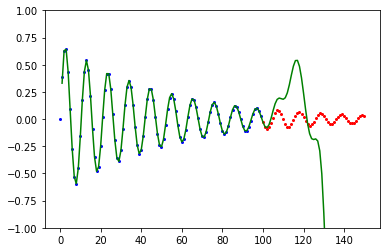

166900 3.6800520536325774e-05 0.5302888442983249


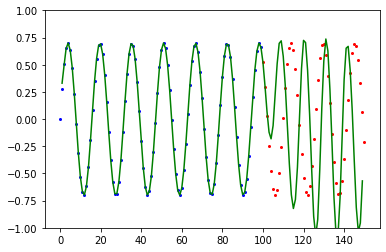

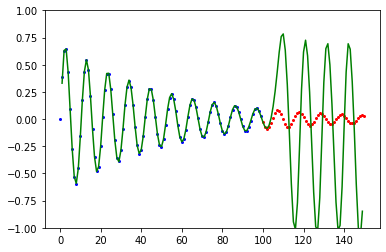

171900 7.69524583914344e-05 0.20212071797025427


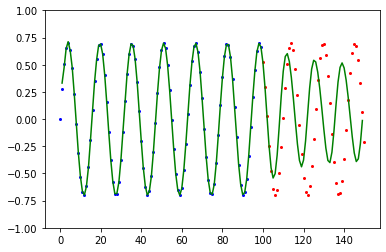

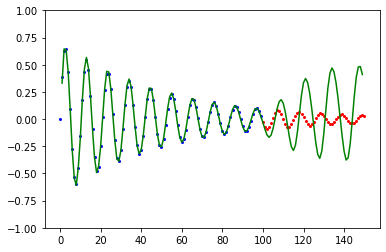

177600 8.734919977659386e-05 0.11746113256837751


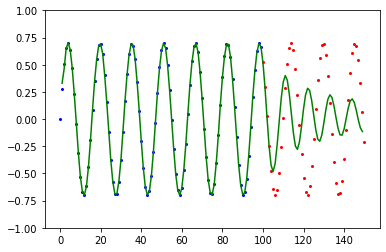

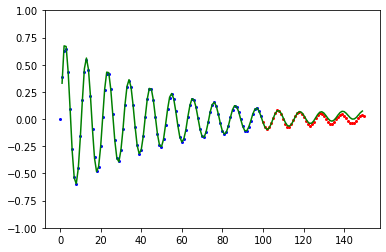

184500 3.9994858626303416e-05 0.3678570152232038


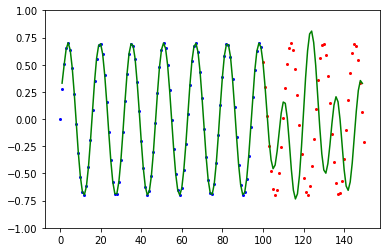

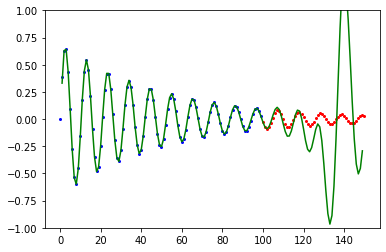

189500 5.0410074817441806e-05 0.21484650395361182


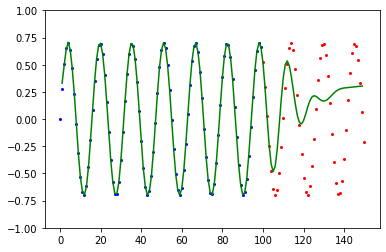

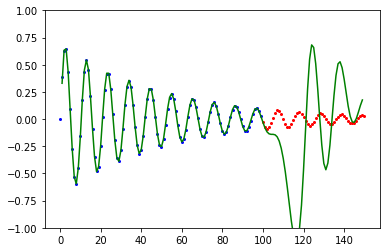

196200 6.907117878384647e-05 0.1268282733817916


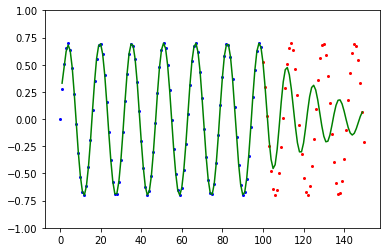

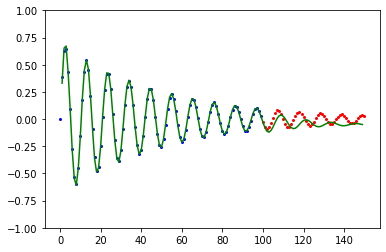

205500 4.950334574897363e-05 0.4323935797378226


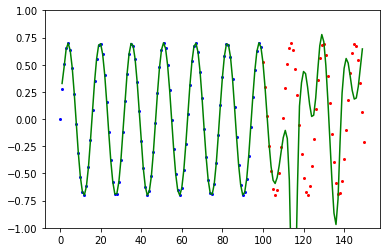

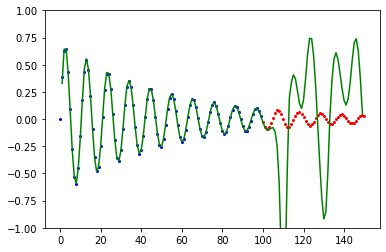

210800 3.540381692200517e-05 0.213715910585454


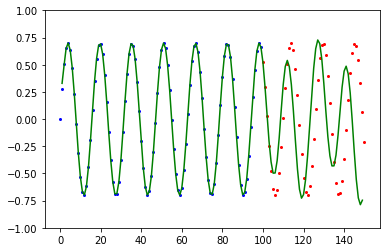

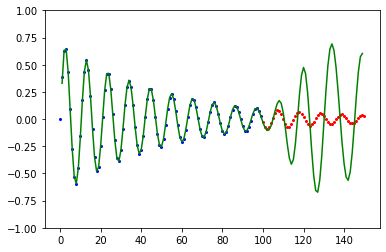

218300 4.6123611283639584e-05 0.46512249451231474


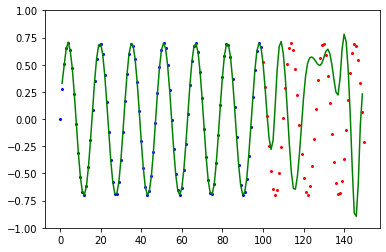

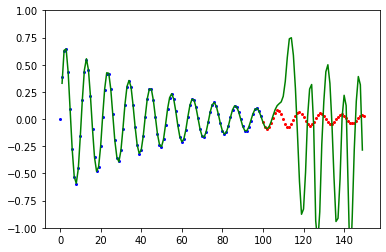

224100 4.8687647587827604e-05 0.10231356194294985


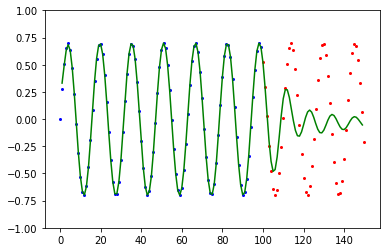

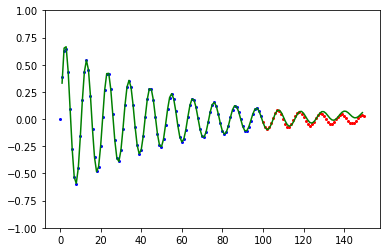

237900 3.3505847133632e-05 0.0024665654548784843


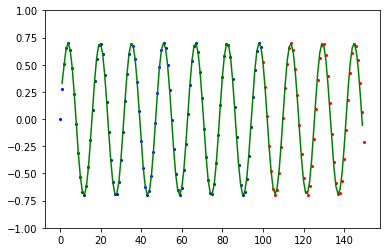

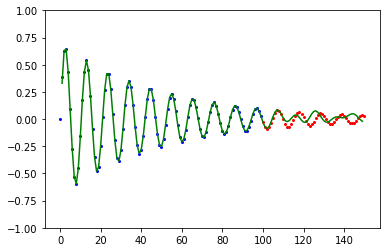

262100 5.020202494809038e-05 0.13498338814875238


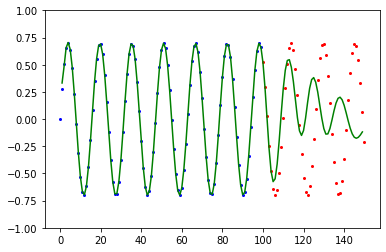

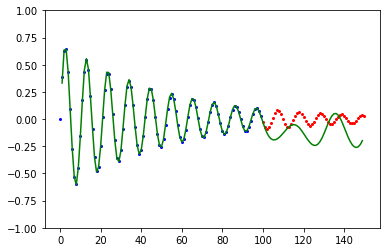

267800 4.112864205481891e-05 2.655973851598633


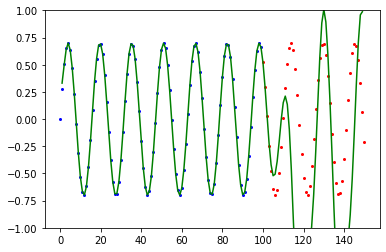

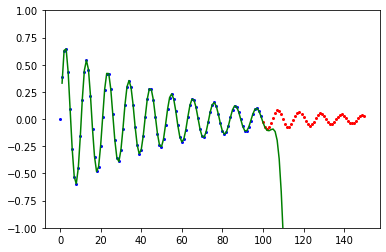

273800 8.118317331245522e-05 0.08783087237393437


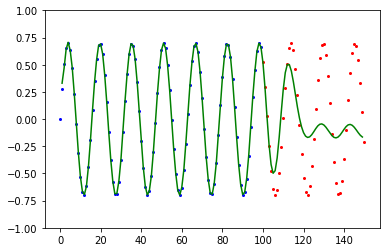

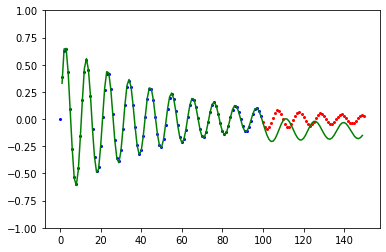

277100 6.918783429858909e-05 0.1097766137142449


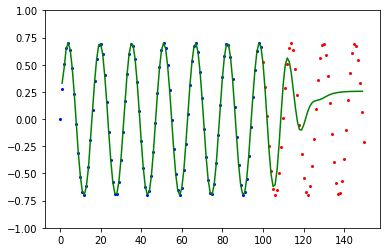

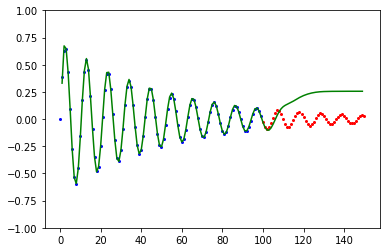

284400 5.2519545732139136e-05 0.6756536253189549


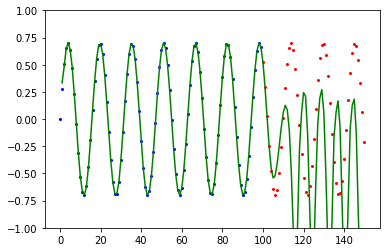

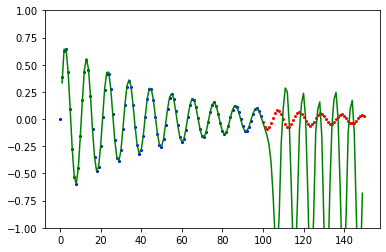

292600 3.9306968936265247e-05 0.13636515867525767


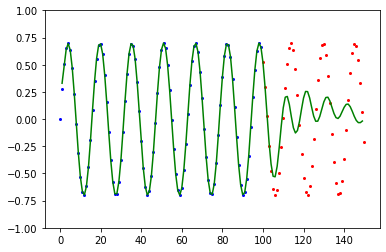

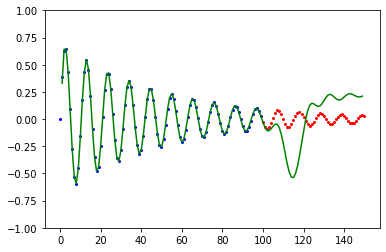

299200 3.4189831254421586e-05 0.15654954749315897


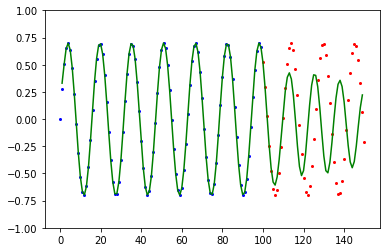

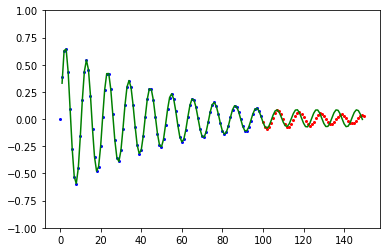

304900 4.3851385218955514e-05 1.156239791169881


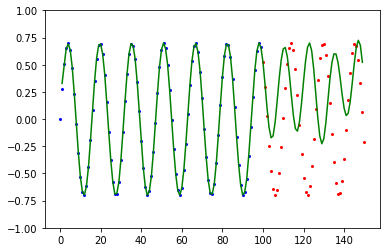

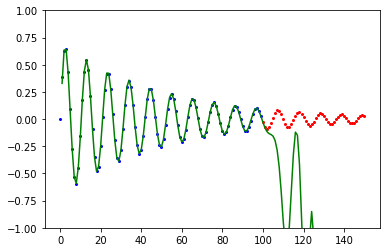

313400 3.496885492876102e-05 0.11036394847541381


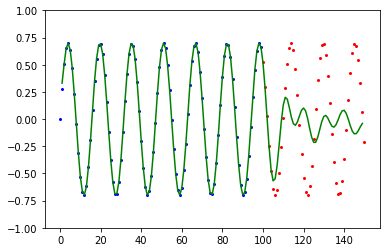

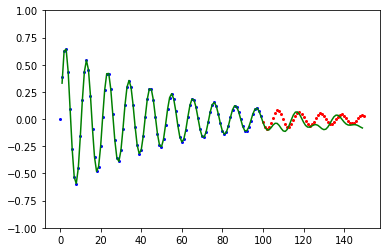

319000 6.343618077253611e-05 0.2795697330538455


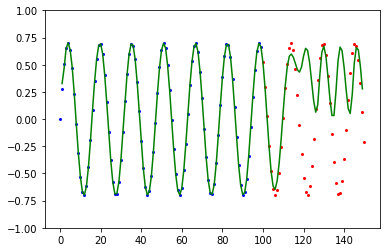

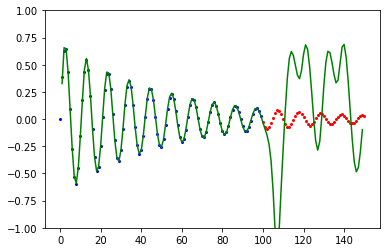

331000 3.874804270050237e-05 9.230111722803567


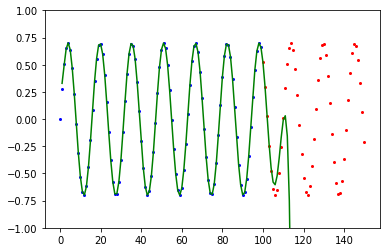

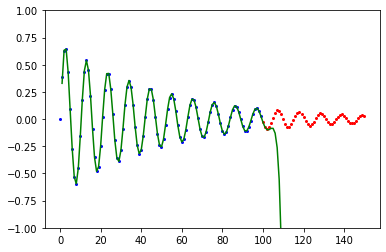

339100 5.9401479942428095e-05 0.14894215297283267


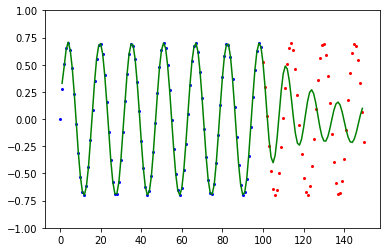

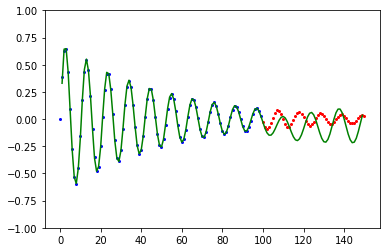

348200 3.4467431487588214e-05 2.0094090740128268


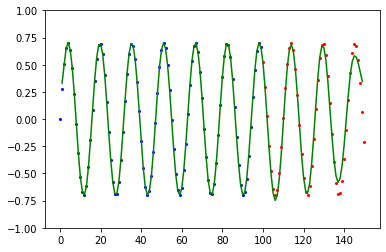

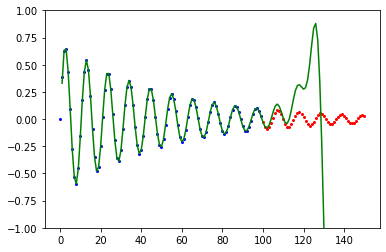

356300 3.596052285581485e-05 0.2398468167394007


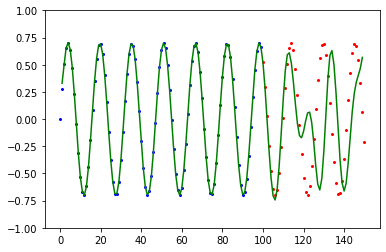

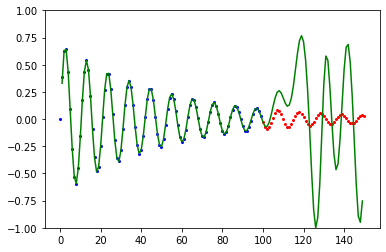

363700 4.2780371752305846e-05 0.43063136616953757


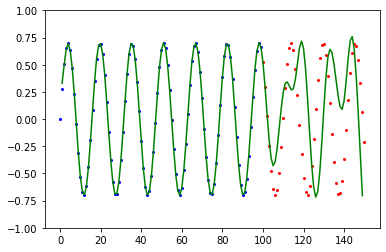

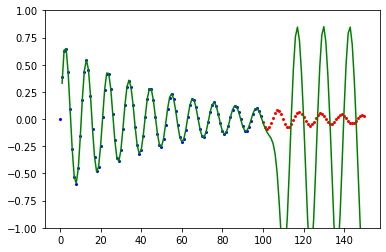

369300 3.745589724572745e-05 0.4903785669339405


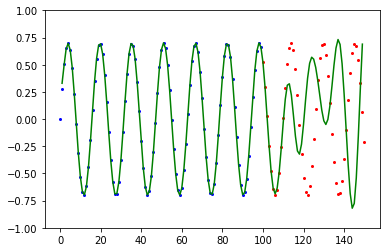

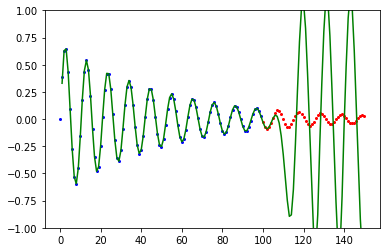

378500 4.11320030393413e-05 2.4550607595425977


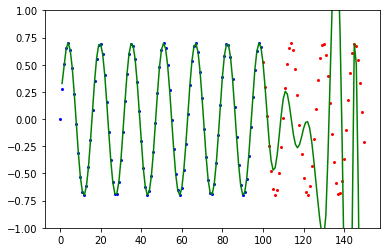

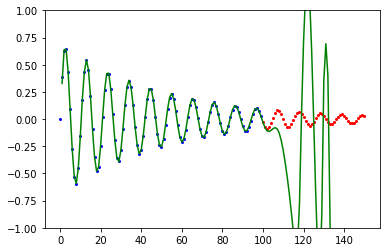

381200 0.0001265616807817109 0.19721227472282754


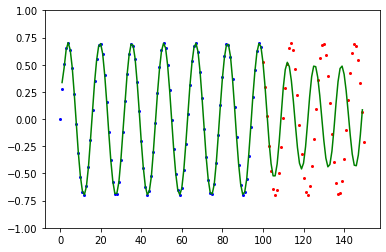

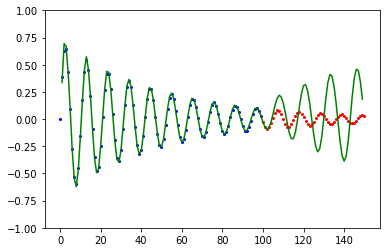

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.77985225, dtype=float64)

In [35]:
len(test_result)

50